In [31]:
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv()
JUN_PATH = os.getenv('NOTEBOOK_JUN_PATH')
SEP_PATH = os.getenv('NOTEBOOK_SEP_PATH')
FIG_PATH = os.getenv('FIG_PATH')

jun_listings = pd.read_csv(f'{JUN_PATH}/listings.csv')
jun_calender = pd.read_csv(f'{JUN_PATH}/calendar.csv')
jun_reviews = pd.read_csv(f'{JUN_PATH}/reviews.csv')
jun_listings = jun_listings.set_index('id')

sep_listings = pd.read_csv(f'{SEP_PATH}/listings.csv')
sep_calender = pd.read_csv(f'{SEP_PATH}/calendar.csv')
sep_reviews = pd.read_csv(f'{SEP_PATH}/reviews.csv')
sep_listings = sep_listings.set_index('id')


print(pd.crosstab(jun_listings['source'], jun_listings['price'].isnull()))
print(pd.crosstab(sep_listings['source'], sep_listings['price'].isnull()))

price            False  True 
source                       
city scrape       5754    110
previous scrape    623   3882
price            False  True 
source                       
city scrape       5874     58
previous scrape      0   4548


In [32]:
def clean_listings(df):
    df = df[df['source'] == 'city scrape'].dropna(subset='price').copy()
    df.loc[:,'price'] = df.loc[:,'price'].str.replace(',','').str.strip('$')
    df['price'] = df['price'].astype(float)
    df['bathroom_shared'] = df['bathrooms_text'].str.contains('shared', case=False, na=False)
    df['bathroom_cleaned'] = df['bathrooms_text'].str.extract(r'(\d+\.?\d*)').astype(float)
    df.loc[df['bathrooms_text'].str.contains('half', case=False, na=False), 'bathroom_cleaned'] = 0.5
    df['bathrooms_final'] = df['bathrooms'].combine_first(df['bathroom_cleaned'])
    return df

def clean_calender(df):
    df['date'] = pd.to_datetime(df['date'])
    return df

In [33]:
def listings_sanity(df):
    print(f"bathrooms missing {df['bathrooms_final'].isnull().sum()}")
    print(df.loc[df['bathroom_cleaned'].isnull() & df['bathrooms_text'].notnull(), 'bathrooms_text'].unique())
    print(df.loc[df['bathrooms_final'].isnull(), ['bathrooms','bathrooms_text']])


In [34]:
def set_date(df, month):
    if month == 'jun':
        df['snapshot_date'] = '2026-06-15'
        return df
    elif month == 'sep':
        df['snapshot_date'] = '2025-09-11'
        return df

In [35]:
jun_listings = clean_listings(jun_listings)
sep_listings = clean_listings(sep_listings)

In [36]:
listings_sanity(jun_listings)
listings_sanity(sep_listings)

bathrooms missing 2
<ArrowStringArray>
[]
Length: 0, dtype: str
                     bathrooms bathrooms_text
id                                           
1542734439719065794        NaN            NaN
1700184827110328413        NaN            NaN
bathrooms missing 0
<ArrowStringArray>
[]
Length: 0, dtype: str
Empty DataFrame
Columns: [bathrooms, bathrooms_text]
Index: []


In [37]:
jun_listings = set_date(jun_listings, 'jun')
sep_listings = set_date(sep_listings, 'sep')

In [8]:
len(set(jun_listings.index) & set(sep_listings.index))

3786

In [9]:
len(set(jun_listings.index)) + len(set(sep_listings.index))

11628

In [38]:
merged_listings = pd.merge(jun_listings, sep_listings, on='id', suffixes=('_2026', '_2025'))
concat_listings = pd.concat([jun_listings, sep_listings], axis=0)

In [39]:
merged_listings = merged_listings[merged_listings['neighbourhood_cleansed_2026'] == merged_listings['neighbourhood_cleansed_2025']]

In [12]:
merged_listings.info()

<class 'pandas.DataFrame'>
Index: 3781 entries, 49552 to 1505255613607359391
Columns: 175 entries, listing_url_2026 to snapshot_date_2025
dtypes: bool(2), float64(73), int64(36), str(64)
memory usage: 21.5 MB


In [13]:
concat_listings.info()

<class 'pandas.DataFrame'>
Index: 11628 entries, 49552 to 1506287353709120640
Data columns (total 93 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   listing_url                                   11628 non-null  str    
 1   scrape_id                                     11628 non-null  int64  
 2   last_scraped                                  11628 non-null  str    
 3   source                                        11628 non-null  str    
 4   name                                          11628 non-null  str    
 5   description                                   11261 non-null  str    
 6   neighborhood_overview                         2755 non-null   object 
 7   picture_url                                   11628 non-null  str    
 8   host_id                                       11628 non-null  int64  
 9   host_url                                      11628 non-nul

In [14]:
jun_calender = clean_calender(jun_calender)
sep_calender = clean_calender(sep_calender)

In [15]:
neighbourhood_df = merged_listings.melt(
    id_vars='neighbourhood_cleansed_2026',
    value_vars=['price_2025', 'price_2026'],
    var_name='year',
    value_name='price'
)

neighbourhood_df['year'] = neighbourhood_df['year'].str.replace('price_', '')

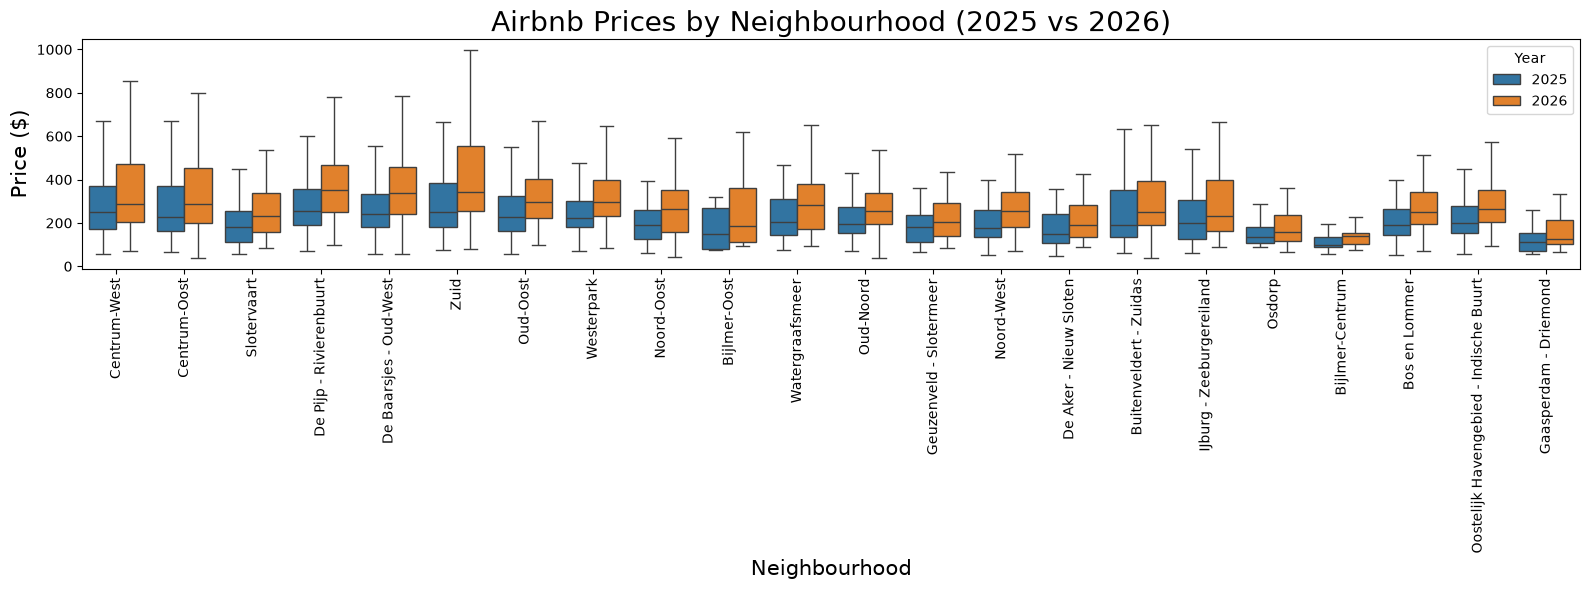

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))

sns.boxplot(
    data=neighbourhood_df,
    x='neighbourhood_cleansed_2026',
    y='price',
    hue='year',
    showfliers=False
)

plt.xticks(rotation=90)
plt.xlabel("Neighbourhood", size=15)
plt.ylabel("Price ($)", size=15)
plt.title("Airbnb Prices by Neighbourhood (2025 vs 2026)", size=20)
plt.legend(title="Year")
plt.tight_layout()

plt.savefig(f'{FIG_PATH}/price_by_neighbourhood_25v26')
plt.show()

In [17]:
room_df = merged_listings.melt(
    id_vars=['room_type_2026'],
    value_vars=['price_2025', 'price_2026'],
    value_name='price',
    var_name='year'
)

room_df['year'] = room_df['year'].str.replace('price_', '')

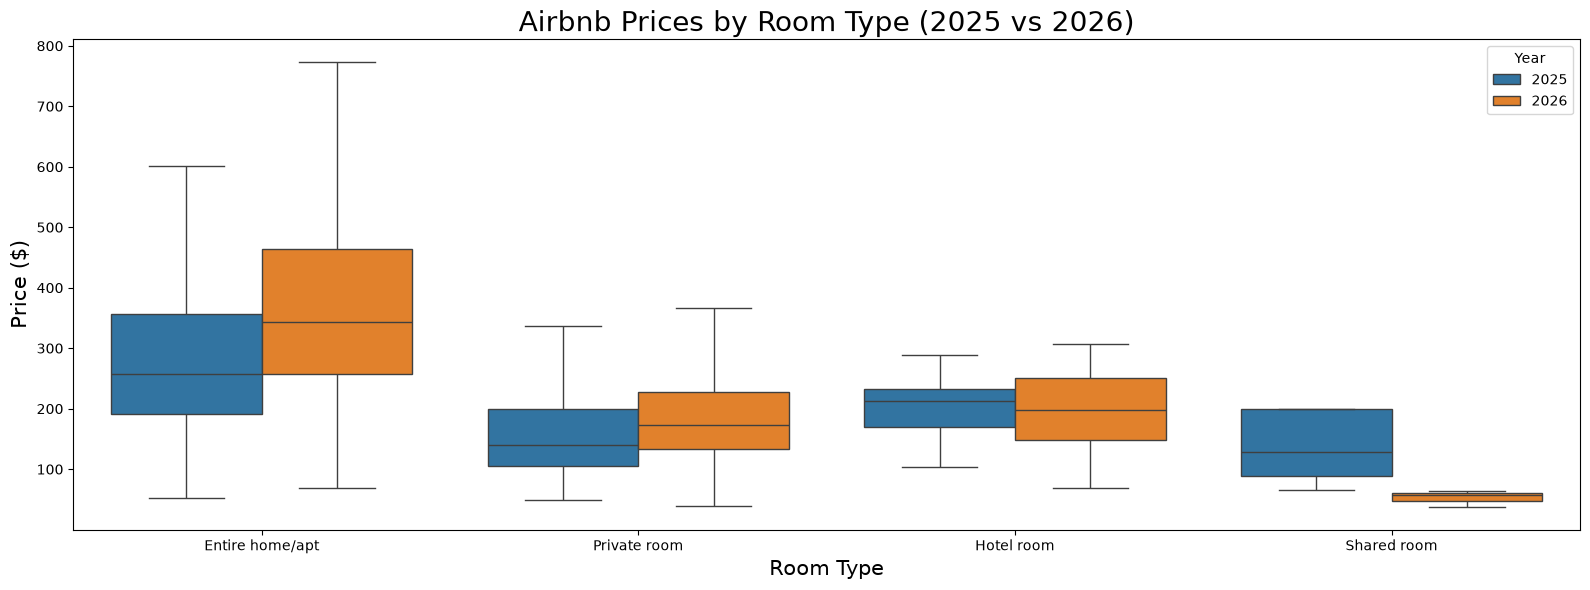

In [18]:
plt.figure(figsize=(16, 6))

sns.boxplot(
    data=room_df,
    x='room_type_2026',
    y='price',
    hue='year',
    showfliers=False
)

plt.xlabel("Room Type", size=15)
plt.ylabel("Price ($)", size=15)
plt.title("Airbnb Prices by Room Type (2025 vs 2026)", size=20)
plt.legend(title="Year")
plt.tight_layout()

plt.savefig(f'{FIG_PATH}/price_by_room_type_25v26')
plt.show()

In [41]:
merged_listings['price_change'] = merged_listings['price_2026'] - merged_listings['price_2025']

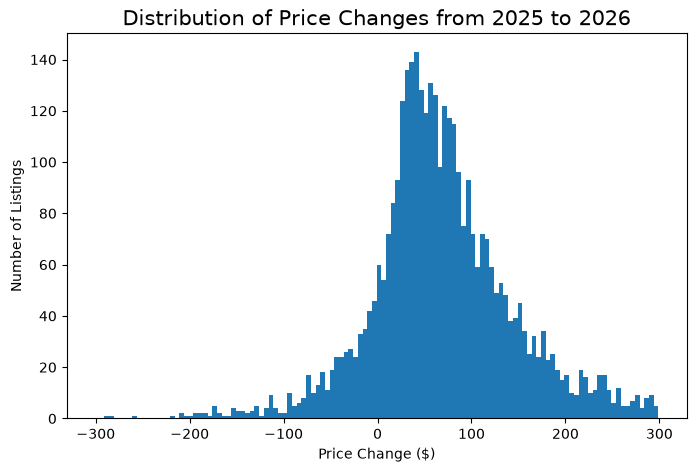

In [49]:
import numpy as np

bins = np.arange(-301, 301, 5)

plt.figure(figsize=(8, 5))
plt.hist(merged_listings['price_change'], bins=bins)

plt.xlabel("Price Change ($)")
plt.ylabel("Number of Listings")
plt.title("Distribution of Price Changes from 2025 to 2026", size=15)

plt.savefig(f'{FIG_PATH}/price_change_dist')
plt.show()

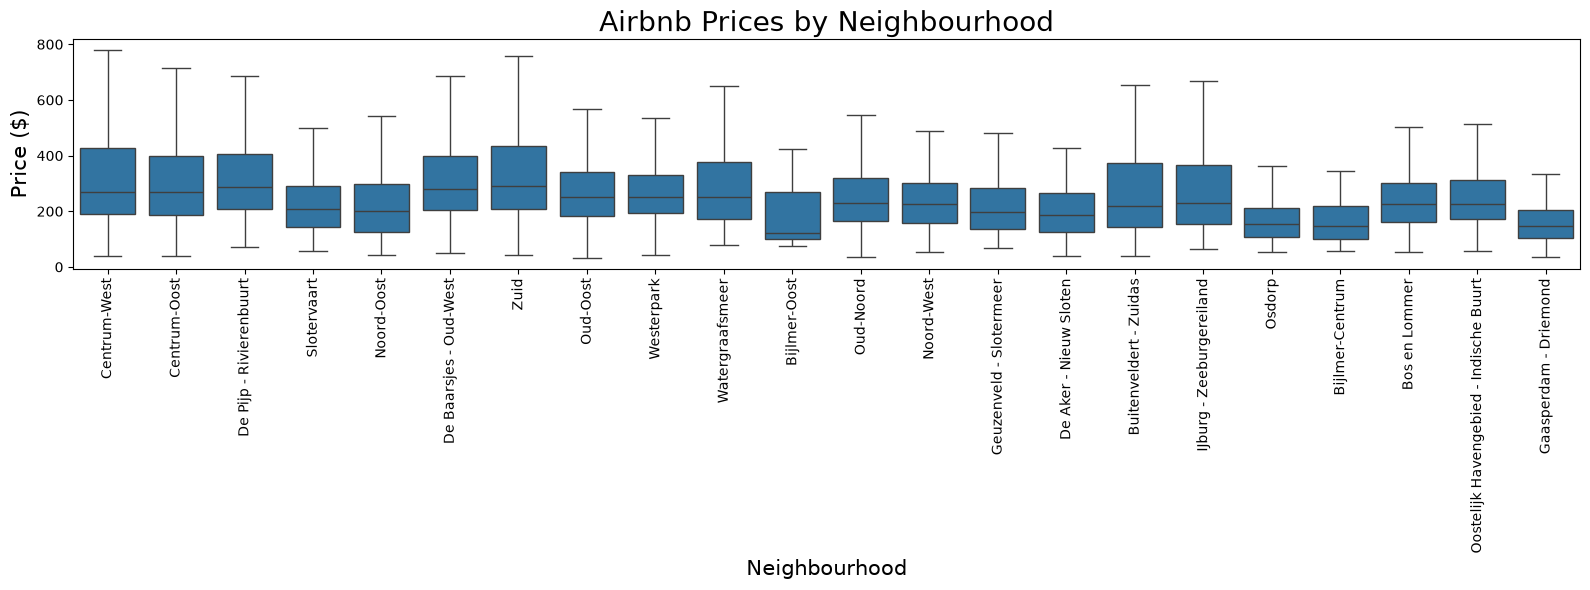

In [21]:
plt.figure(figsize=(16, 6))

sns.boxplot(
    data=concat_listings,
    x='neighbourhood_cleansed',
    y='price',
    showfliers=False
)

plt.xticks(rotation=90)
plt.xlabel("Neighbourhood", size=15)
plt.ylabel("Price ($)", size=15)
plt.title("Airbnb Prices by Neighbourhood", size=20)
plt.tight_layout()

plt.savefig(f'{FIG_PATH}/price_by_neighbourhood')
plt.show()

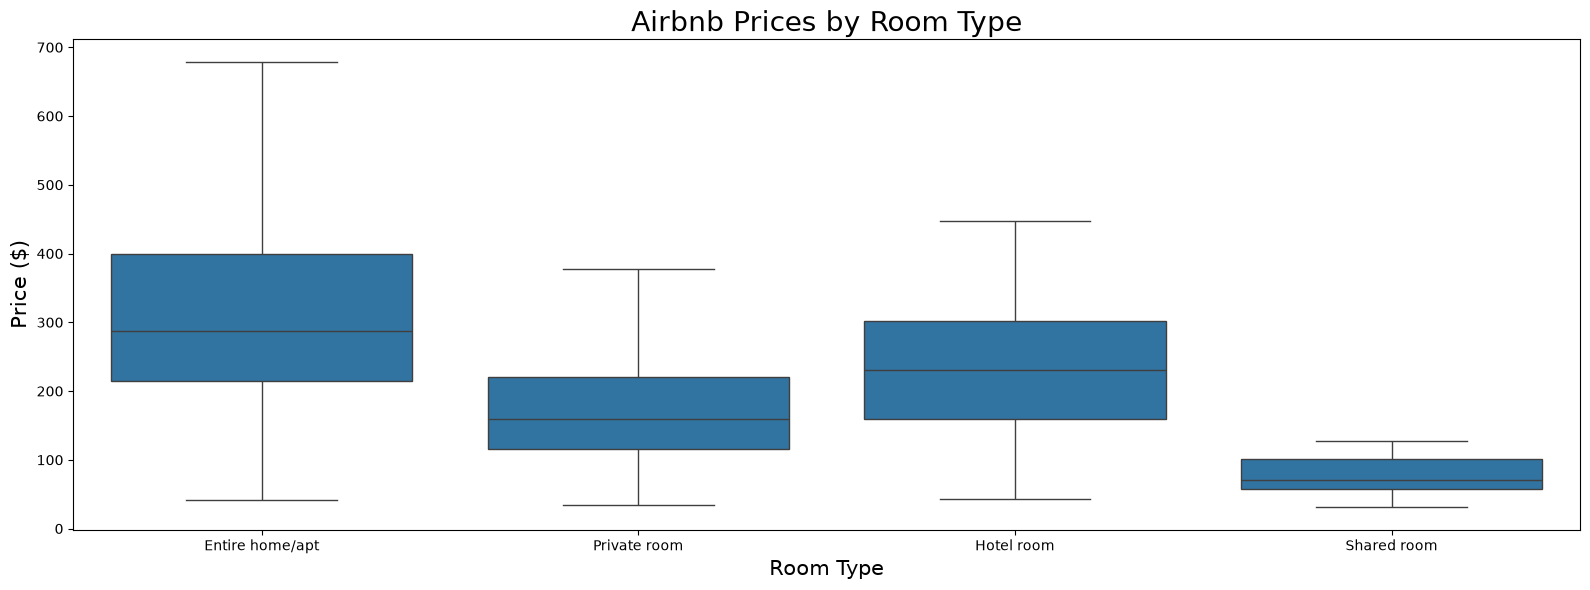

In [22]:
plt.figure(figsize=(16, 6))

sns.boxplot(
    data=concat_listings,
    x='room_type',
    y='price',
    showfliers=False
)

plt.xlabel("Room Type", size=15)
plt.ylabel("Price ($)", size=15)
plt.title("Airbnb Prices by Room Type", size=20)
plt.tight_layout()

plt.savefig(f'{FIG_PATH}/price_by_room_type')
plt.show()

In [23]:
sep_ratios = sep_calender.groupby('date')['available'].value_counts(normalize=True)
sep_f_ratios = sep_ratios.xs('f', level='available')
sep_ratios_df = sep_f_ratios.reset_index(name='ratio')

jun_ratios = jun_calender.groupby('date')['available'].value_counts(normalize=True)
jun_f_ratios = jun_ratios.xs('f', level='available')
jun_ratios_df = jun_f_ratios.reset_index(name='ratio')

sep_ratios_df['dataset'] = 'September 2025 snapshot'
jun_ratios_df['dataset'] = 'June 2026 snapshot'

plot_df = pd.concat([sep_ratios_df, jun_ratios_df], ignore_index=True)

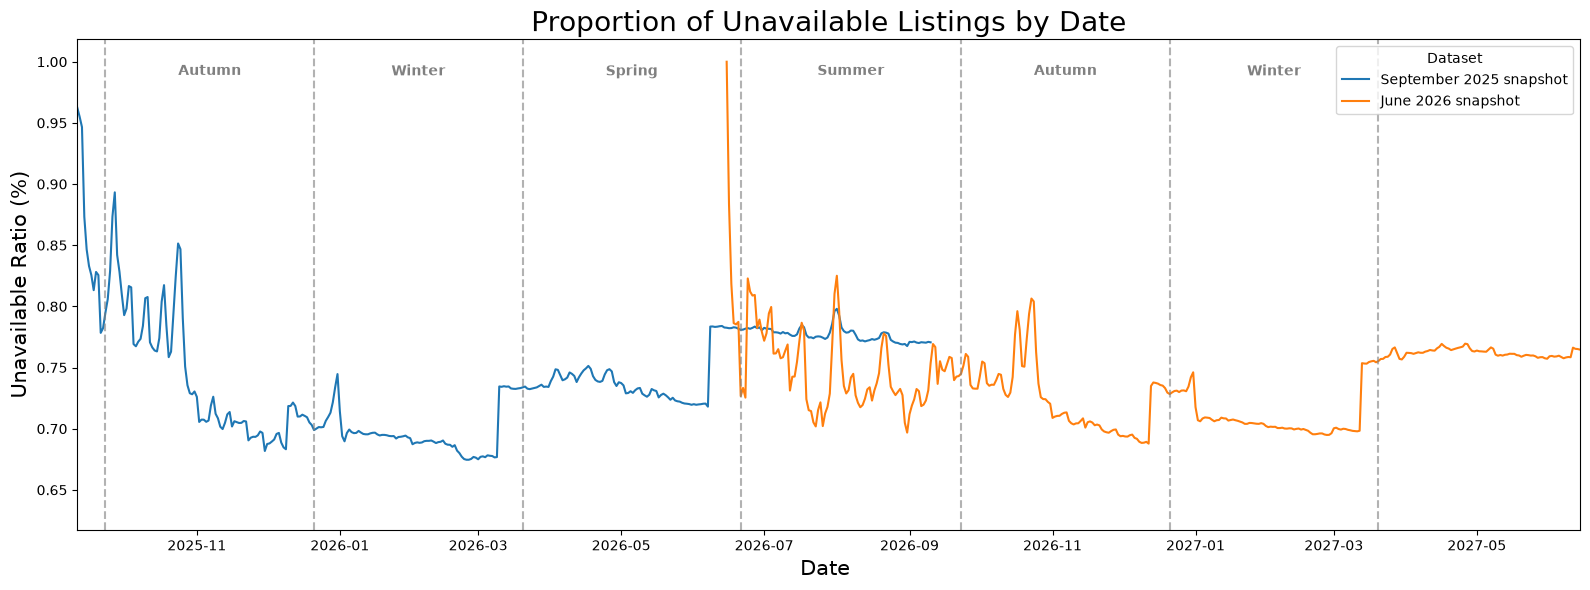

In [24]:
season_starts = [
    ("Autumn", pd.Timestamp("2025-09-23")),
    ("Winter", pd.Timestamp("2025-12-21")),
    ("Spring", pd.Timestamp("2026-03-20")),
    ("Summer", pd.Timestamp("2026-06-21")),
    ("Autumn", pd.Timestamp("2026-09-23")),
    ("Winter", pd.Timestamp("2026-12-21")),
    ("Spring", pd.Timestamp("2027-03-20")),
]

plt.figure(figsize=(16, 6))

sns.lineplot(
    data=plot_df,
    x='date',
    y='ratio',
    hue='dataset'
)

ax = plt.gca()

for _, date in season_starts:
    ax.axvline(date, color="gray", linestyle="--", alpha=0.6)

for i in range(len(season_starts) - 1):
    season, start = season_starts[i]
    _, end = season_starts[i + 1]

    midpoint = start + (end - start) / 2

    ax.text(
        midpoint,
        ax.get_ylim()[1] * 0.98,
        season,
        ha="center",
        va="top",
        fontsize=10,
        weight="bold",
        color="gray"
    )
plt.xlim(pd.Timestamp("2025-09-11"), pd.Timestamp("2027-06-14"))


plt.xlabel("Date ", size=15)
plt.ylabel("Unavailable Ratio (%)", size=15)
plt.title("Proportion of Unavailable Listings by Date", size=20)
plt.legend(title='Dataset')
plt.tight_layout()

plt.savefig(f'{FIG_PATH}/proportion_of_unavailable_listings_by_date')
plt.show()

In [25]:
concat_calenders = pd.concat([jun_calender, sep_calender], axis=0)

In [26]:
merged_listings.to_parquet('/home/emad/Documents/projects/airbnb/data/merged_listings.parquet')
concat_listings.to_parquet('/home/emad/Documents/projects/airbnb/data/concat_listings.parquet')
concat_calenders.to_parquet('/home/emad/Documents/projects/airbnb/data/concat_calenders.parquet')

In [27]:
with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None
):
    display(concat_listings['property_type'].value_counts())


property_type
Entire rental unit                    4621
Entire condo                          1704
Entire home                           1265
Private room in rental unit            567
Private room in bed and breakfast      495
Room in hotel                          287
Private room in condo                  286
Entire loft                            275
Houseboat                              225
Private room in home                   212
Entire townhouse                       196
Entire serviced apartment              195
Boat                                   162
Room in boutique hotel                 145
Private room in houseboat              132
Private room in townhouse              113
Private room in guest suite            105
Entire guesthouse                       68
Private room in boat                    66
Entire guest suite                      62
Private room in loft                    57
Private room in guesthouse              57
Shared room in hotel                    

In [28]:
pd.to_datetime(concat_listings['last_review'])

id
49552                 2026-06-07
50263                 2026-06-04
50523                 2026-05-31
91535                 2026-06-13
97221                 2026-05-24
                         ...    
1503867342263201504          NaT
1504985777531398085          NaT
1504998100462399057          NaT
1505255613607359391          NaT
1506287353709120640          NaT
Name: last_review, Length: 11628, dtype: datetime64[us]